Data Preperation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

INCOME_DATA_PATH = "income_data.csv"

# Big dataset path (for part g)
INCOME_BIG_DATA_PATH = "income_big.csv"

INCOME_INFO_PATH = "income_info.txt"


In [2]:
# Define column names for the 14 attributes

columns = [
    "Annual_Income",       # 1
    "Sex",                 # 2
    "Marital_Status",      # 3
    "Age",                 # 4
    "Education",           # 5
    "Occupation",          # 6
    "Years_in_Area",       # 7
    "Dual_Income",         # 8
    "Household_Size",      # 9
    "Under18_in_HH",       # 10
    "Householder_Status",  # 11
    "Home_Type",           # 12
    "Ethnicity",           # 13
    "Language"             # 14
]


In [3]:
# Load CSV with column names and NA handling
df = pd.read_csv(INCOME_DATA_PATH, header=None, names=columns, na_values="NA")

# Inspect first rows
print(df.head())

# Check shape
print("Dataset shape:", df.shape)

# Count missing values per column
print(df.isna().sum())

   Annual_Income  Sex  Marital_Status  Age  Education  Occupation  \
0              9    2             1.0    5        4.0         5.0   
1              9    1             1.0    5        5.0         5.0   
2              9    2             1.0    3        5.0         1.0   
3              1    2             5.0    1        2.0         6.0   
4              1    2             5.0    1        2.0         6.0   

   Years_in_Area  Dual_Income  Household_Size  Under18_in_HH  \
0            5.0            3             3.0              0   
1            5.0            3             5.0              2   
2            5.0            2             3.0              1   
3            5.0            1             4.0              2   
4            3.0            1             4.0              2   

   Householder_Status  Home_Type  Ethnicity  Language  
0                 1.0        1.0        7.0       NaN  
1                 1.0        1.0        7.0       1.0  
2                 2.0        3.0

In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8993 entries, 0 to 8992
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       8993 non-null   int64  
 1   Sex                 8993 non-null   int64  
 2   Marital_Status      8833 non-null   float64
 3   Age                 8993 non-null   int64  
 4   Education           8907 non-null   float64
 5   Occupation          8857 non-null   float64
 6   Years_in_Area       8080 non-null   float64
 7   Dual_Income         8993 non-null   int64  
 8   Household_Size      8618 non-null   float64
 9   Under18_in_HH       8993 non-null   int64  
 10  Householder_Status  8753 non-null   float64
 11  Home_Type           8636 non-null   float64
 12  Ethnicity           8925 non-null   float64
 13  Language            8634 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 983.7 KB


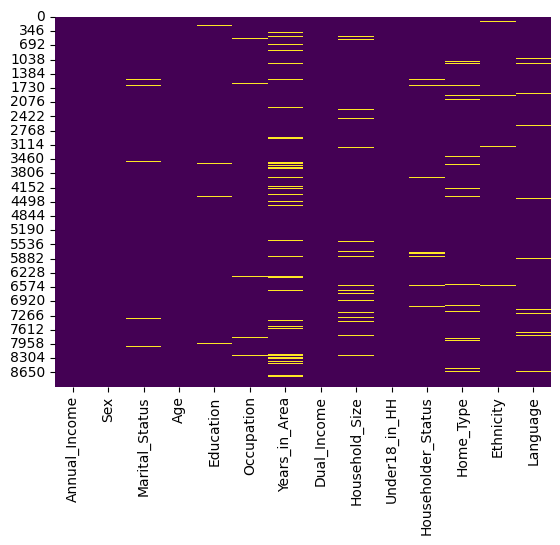

In [5]:
# Missing data visualization
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.show()

In [6]:
# Handling missing values via mode imputation
clean_df = df.copy()

for col in clean_df.columns:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

In [7]:
# Assessing imputation results
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8993 entries, 0 to 8992
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       8993 non-null   int64  
 1   Sex                 8993 non-null   int64  
 2   Marital_Status      8993 non-null   float64
 3   Age                 8993 non-null   int64  
 4   Education           8993 non-null   float64
 5   Occupation          8993 non-null   float64
 6   Years_in_Area       8993 non-null   float64
 7   Dual_Income         8993 non-null   int64  
 8   Household_Size      8993 non-null   float64
 9   Under18_in_HH       8993 non-null   int64  
 10  Householder_Status  8993 non-null   float64
 11  Home_Type           8993 non-null   float64
 12  Ethnicity           8993 non-null   float64
 13  Language            8993 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 983.7 KB


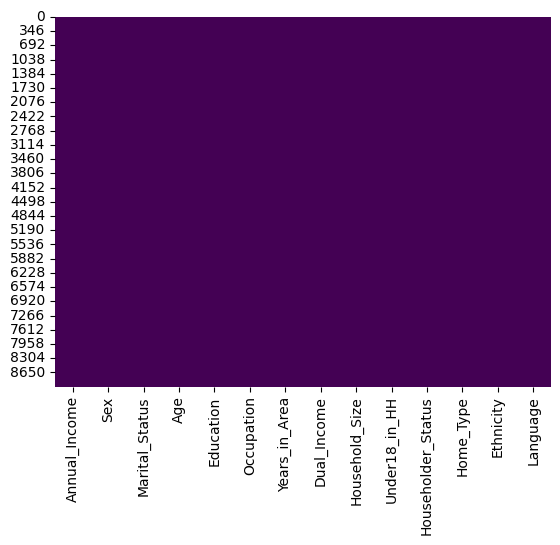

In [8]:
# Missing data visualization
sns.heatmap(clean_df.isna(), cbar=False, cmap="viridis")
plt.show()

## Part A
Without using a decision tree, investigate the relation between the annual income and the other demographic predictors.

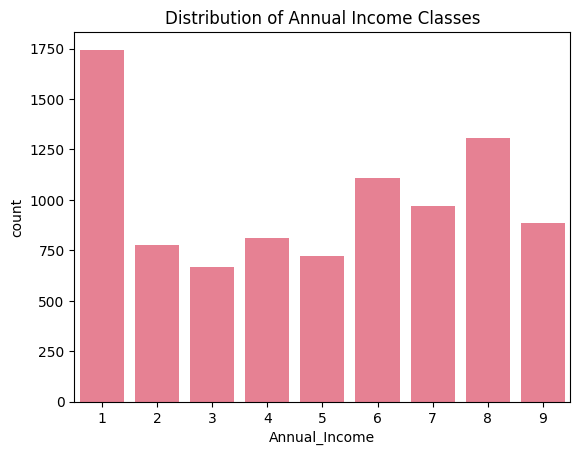

In [9]:
#See Income Distribution

sns.countplot(x="Annual_Income", data=clean_df, order=sorted(clean_df["Annual_Income"].unique()))
plt.title("Distribution of Annual Income Classes")
plt.show()

In [10]:
# Chi-Square Test of Independence to test whether income is statistically dependent on each categorical feature:

from scipy.stats import chi2_contingency

for col in clean_df.columns[1:]:
    contingency = pd.crosstab(clean_df[col], clean_df["Annual_Income"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: p-value = {p:.4f}")

Sex: p-value = 0.0001
Marital_Status: p-value = 0.0000
Age: p-value = 0.0000
Education: p-value = 0.0000
Occupation: p-value = 0.0000
Years_in_Area: p-value = 0.0000
Dual_Income: p-value = 0.0000
Household_Size: p-value = 0.0000
Under18_in_HH: p-value = 0.0000
Householder_Status: p-value = 0.0000
Home_Type: p-value = 0.0000
Ethnicity: p-value = 0.0000
Language: p-value = 0.0000


In [11]:
# Measuring the strength of the association with Cramer's V.

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in clean_df.columns:
    if col != "Annual_Income":
        v = cramers_v(clean_df[col], clean_df["Annual_Income"])
        print(f"{col}: {v:.3f}")


Sex: 0.050
Marital_Status: 0.262
Age: 0.279
Education: 0.265
Occupation: 0.228
Years_in_Area: 0.048
Dual_Income: 0.316
Household_Size: 0.107
Under18_in_HH: 0.081
Householder_Status: 0.456
Home_Type: 0.151
Ethnicity: 0.069
Language: 0.091


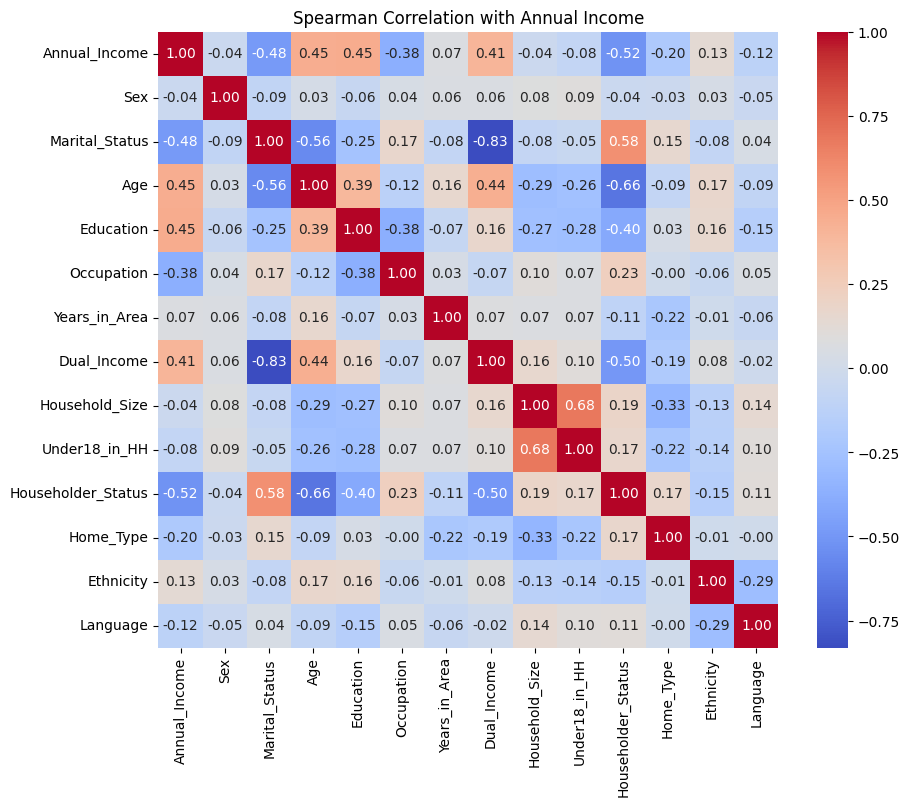

Annual_Income         1.000000
Education             0.451420
Age                   0.446852
Dual_Income           0.406357
Ethnicity             0.130755
Years_in_Area         0.067967
Household_Size       -0.035499
Sex                  -0.038588
Under18_in_HH        -0.083515
Language             -0.119408
Home_Type            -0.196328
Occupation           -0.376393
Marital_Status       -0.480469
Householder_Status   -0.517593
Name: Annual_Income, dtype: float64


In [12]:
#Assessing direction via Correlation Heatmap -  applicable to ordinal variables

corr = clean_df.corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation with Annual Income")
plt.show()

print(corr["Annual_Income"].sort_values(ascending=False))

In [13]:
# Cross-tabs: each predictor vs. Annual_Income
for col in clean_df.columns:
    if col != "Annual_Income":
        print(f"\n {col} vs. Annual_Income")
        ct = pd.crosstab(clean_df[col], clean_df["Annual_Income"], normalize="index")  # row-normalized
        display(ct.round(3))  # show row percentages


 Sex vs. Annual_Income


Annual_Income,1,2,3,4,5,6,7,8,9
Sex,,,,,,,,,
1,0.173,0.088,0.074,0.091,0.086,0.128,0.112,0.141,0.107
2,0.212,0.085,0.074,0.090,0.075,0.120,0.104,0.149,0.091



 Marital_Status vs. Annual_Income


Annual_Income,1,2,3,4,5,6,7,8,9
Marital_Status,,,,,,,,,
1.0,0.031,0.043,0.040,0.065,0.079,0.155,0.160,0.250,0.178
2.0,0.120,0.109,0.109,0.133,0.076,0.130,0.084,0.147,0.091
3.0,0.102,0.102,0.115,0.142,0.119,0.157,0.130,0.090,0.043
4.0,0.152,0.172,0.116,0.142,0.103,0.093,0.103,0.076,0.043
5.0,0.374,0.110,0.085,0.089,0.071,0.089,0.061,0.072,0.047



 Age vs. Annual_Income


...

Annual_Income,1,2,3,4,5,6,7,8,9
Home_Type,,,,,,,,,
1.0,0.196,0.064,0.056,0.070,0.065,0.120,0.113,0.180,0.136
2.0,0.125,0.047,0.049,0.084,0.089,0.153,0.156,0.200,0.098
3.0,0.199,0.131,0.118,0.139,0.112,0.124,0.088,0.069,0.020
4.0,0.166,0.166,0.113,0.139,0.113,0.152,0.073,0.026,0.053
5.0,0.271,0.156,0.091,0.078,0.076,0.102,0.089,0.076,0.062



 Ethnicity vs. Annual_Income


Annual_Income,1,2,3,4,5,6,7,8,9
Ethnicity,,,,,,,,,
1.0,0.247,0.127,0.067,0.140,0.033,0.100,0.080,0.120,0.087
2.0,0.247,0.071,0.063,0.073,0.055,0.130,0.124,0.134,0.103
3.0,0.215,0.102,0.087,0.105,0.080,0.124,0.099,0.144,0.043
4.0,0.444,0.000,0.111,0.000,0.167,0.000,0.111,0.167,0.000
5.0,0.272,0.108,0.107,0.093,0.106,0.123,0.084,0.080,0.024
6.0,0.204,0.117,0.078,0.058,0.097,0.097,0.146,0.107,0.097
7.0,0.167,0.079,0.067,0.088,0.078,0.124,0.112,0.162,0.123
8.0,0.222,0.076,0.062,0.102,0.071,0.120,0.116,0.142,0.089



 Language vs. Annual_Income


Annual_Income,1,2,3,4,5,6,7,8,9
Language,,,,,,,,,
1.0,0.181,0.084,0.072,0.091,0.081,0.127,0.109,0.152,0.103
2.0,0.326,0.123,0.102,0.085,0.079,0.095,0.090,0.071,0.029
3.0,0.310,0.077,0.069,0.092,0.073,0.077,0.100,0.092,0.111


## Part B

Divide your data into 60% train and 40% test. Create the default C&R decision tree.

In [14]:
# Train / Test split (60% train, 40% test)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features & target
X = clean_df.drop(columns=["Annual_Income"])
y = clean_df["Annual_Income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Default C&R decision tree (CART with Gini impurity)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)


Tree depth: 28
Number of leaves: 3163

Text view of top levels of the tree:
|--- Age <= 1.50
|   |--- Occupation <= 5.50
|   |   |--- Householder_Status <= 1.50
|   |   |   |--- Years_in_Area <= 3.50
|   |   |   |   |--- class: 9
|   |   |   |--- Years_in_Area >  3.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- Householder_Status >  1.50
|   |   |   |--- Occupation <= 1.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Occupation >  1.50
|   |   |   |   |--- truncated branch of depth 15
|   |--- Occupation >  5.50
|   |   |--- Occupation <= 6.50
|   |   |   |--- Dual_Income <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- Dual_Income >  2.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Occupation >  6.50
|   |   |   |--- Household_Size <= 2.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Household_Size >  2.50
|   |   |   |   |--- truncated branch of depth 13
|--- Age >  1.50
|   |--- Householder_Status <

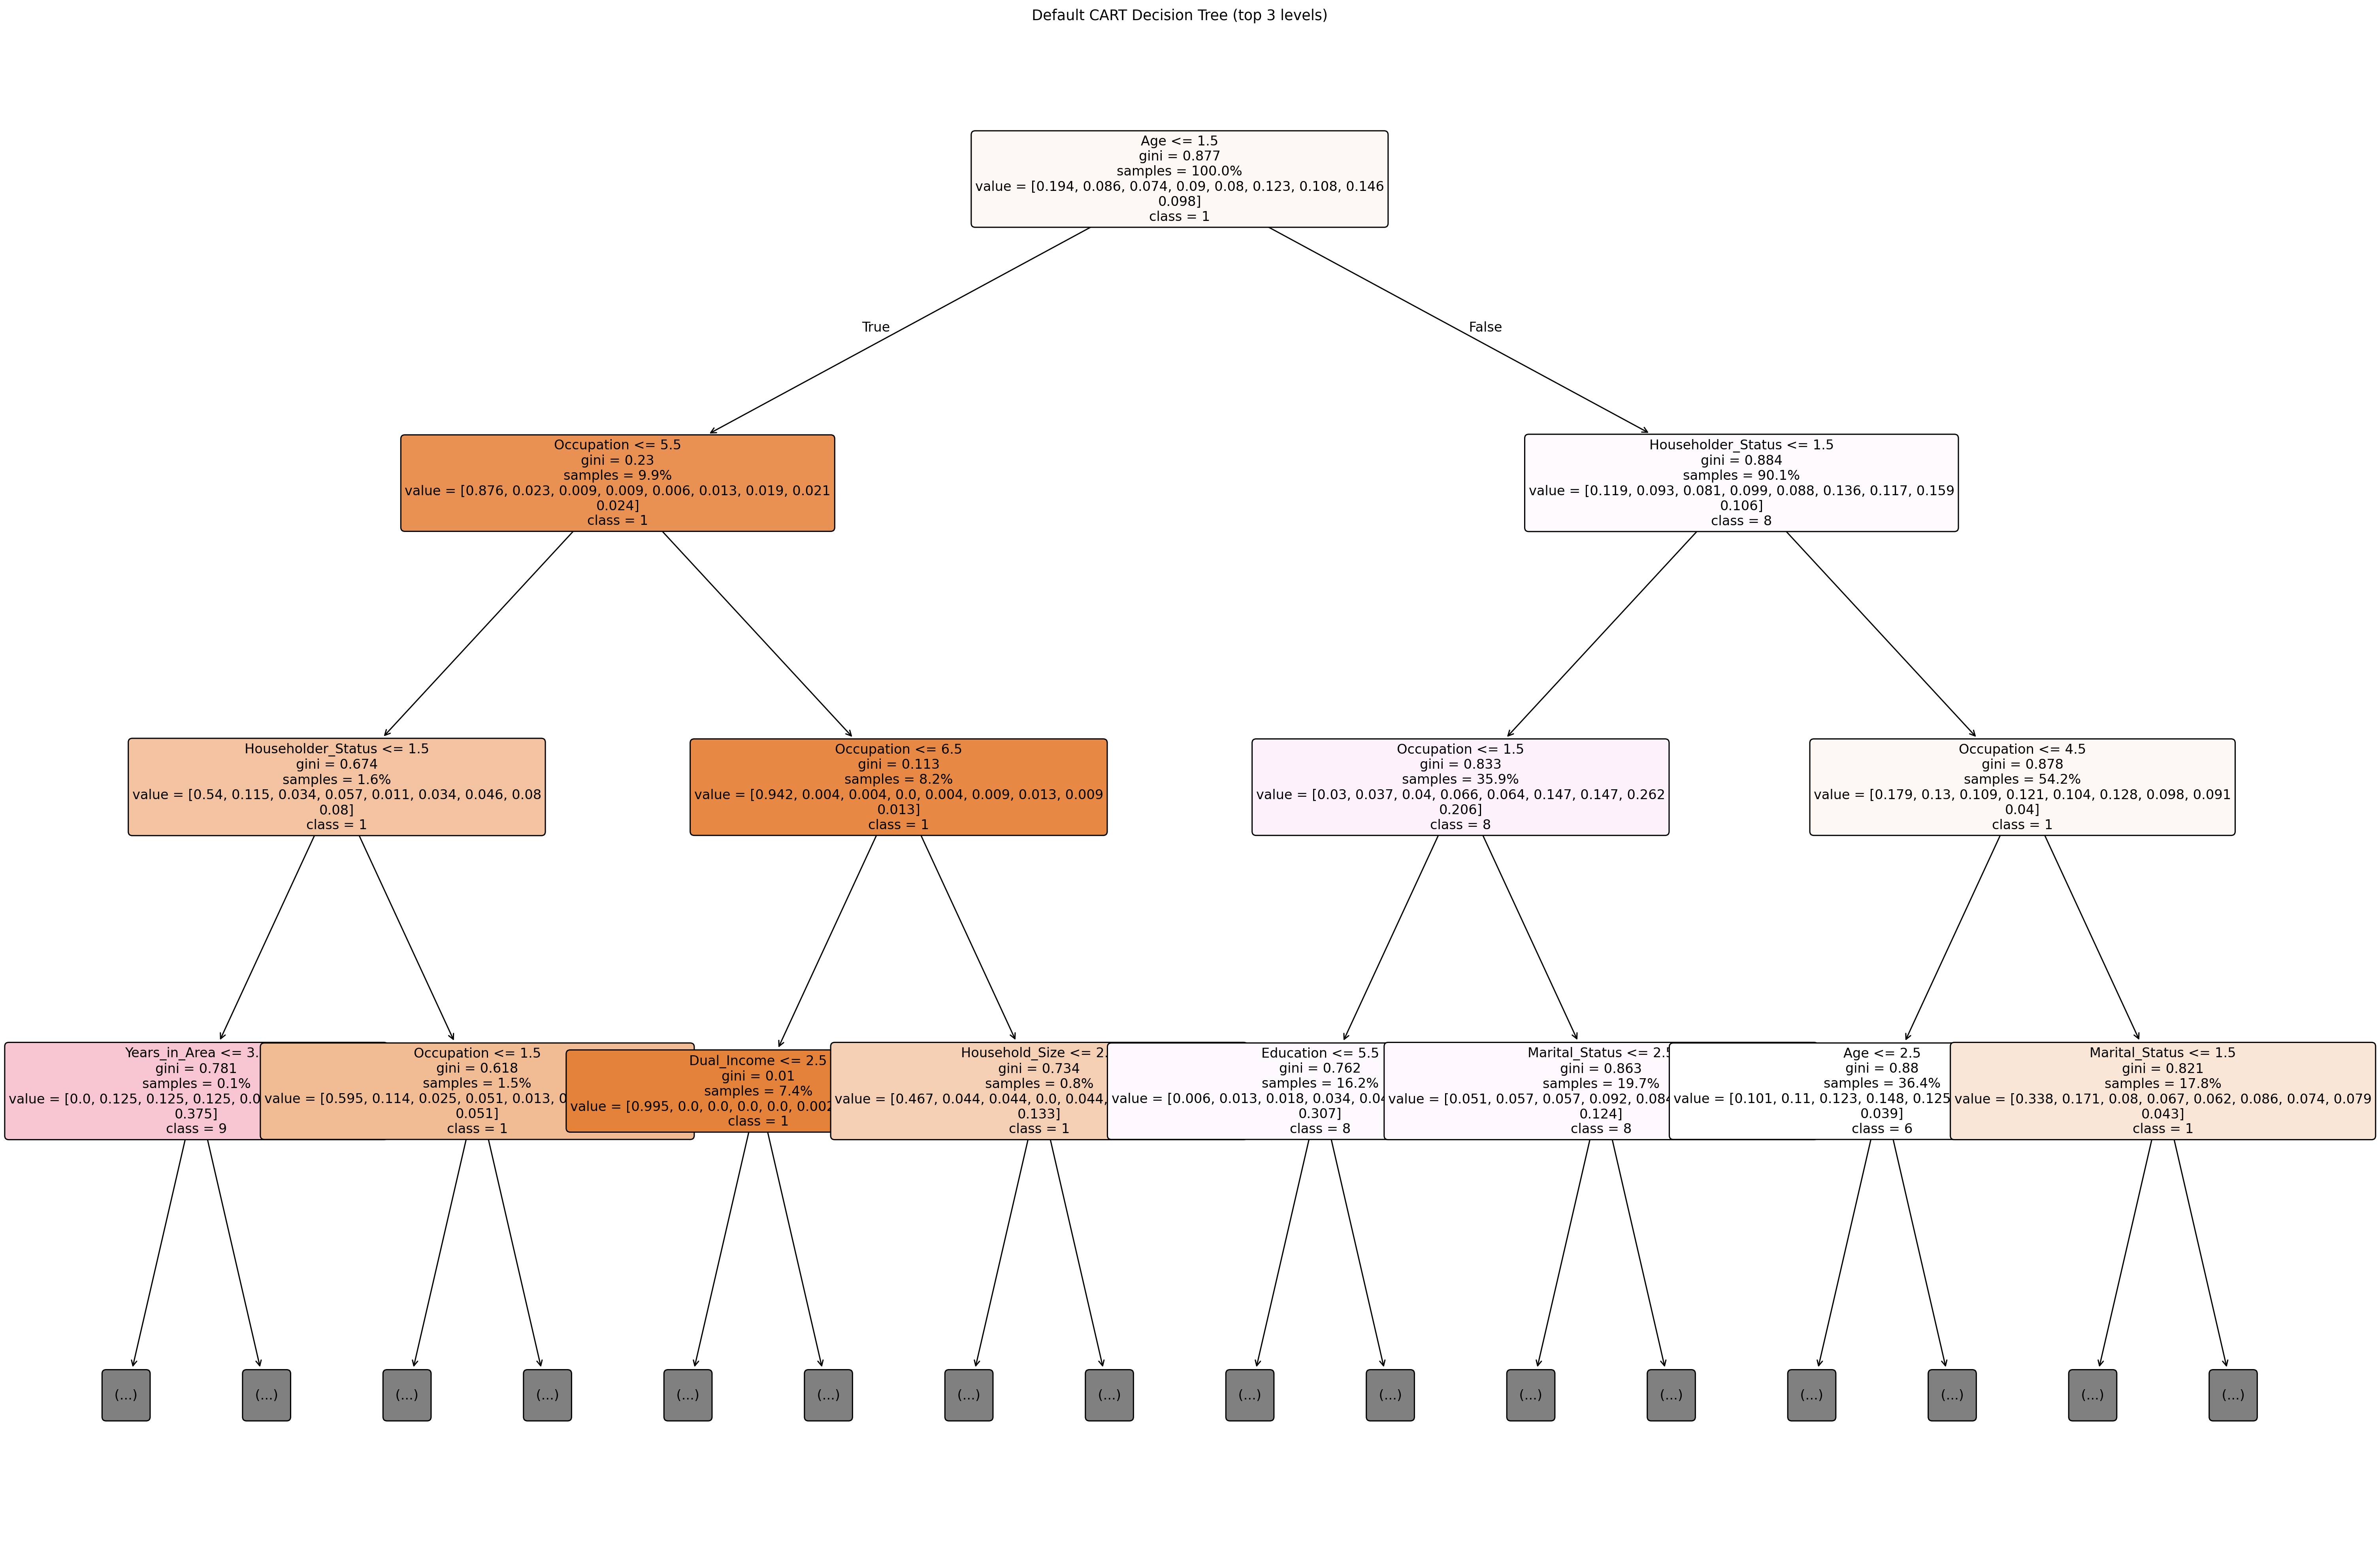

In [15]:
# Model overvieww
print(f"\nTree depth: {dt_default.get_depth()}")
print(f"Number of leaves: {dt_default.get_n_leaves()}")

# Tree text view
print("\nText view of top levels of the tree:")
print(export_text(dt_default, feature_names=list(X.columns), max_depth=3))

# Plotting the tree with limited depth for readability
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
max_plot_depth = 3

plt.rcParams['figure.dpi'] = 220
plt.figure(figsize=(28, 18))

plot_tree(
    dt_default,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    max_depth=max_plot_depth,
    fontsize=11
)
plt.title(f"Default CART Decision Tree (top {max_plot_depth} levels)")
plt.tight_layout()
plt.show()

In [16]:
tree = dt_default.tree_

# Find leaf nodes
leaf_ids = np.where(tree.children_left == -1)[0]

# Get sample counts for each leaf
leaf_sizes = tree.n_node_samples[leaf_ids]

print("Number of leaves:", len(leaf_ids))
print("First 20 leaf sizes:", leaf_sizes[:20])
print("Smallest leaf size:", leaf_sizes.min())
print("Largest leaf size:", leaf_sizes.max())
print("Average leaf size:", leaf_sizes.mean())

Number of leaves: 3163
First 20 leaf sizes: [ 2  1  1  1  1  1  1  1 15  1  1  1  1  1  2  1  1  1  8  2]
Smallest leaf size: 1
Largest leaf size: 397
Average leaf size: 1.7056591843186848


---

## Part C

What are the major predictors of income? How are they related to your observations in part (a)? How well
your decision tree can predict a household’s income in your training data?

In [17]:
# Major Predictors of Income
fi = pd.Series(dt_default.feature_importances_, index=X.columns)
fi = fi.sort_values(ascending=False)
print(fi)

y_pred = dt_default.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (test): {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

train_acc = dt_default.score(X_train, y_train)
print("Training Accuracy:", train_acc)

Age                   0.153278
Occupation            0.104779
Household_Size        0.100513
Ethnicity             0.099693
Education             0.097271
Years_in_Area         0.094544
Home_Type             0.084976
Under18_in_HH         0.063767
Marital_Status        0.053440
Sex                   0.047984
Householder_Status    0.039072
Dual_Income           0.036396
Language              0.024286
dtype: float64
Accuracy (test): 0.2818

Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.61      0.61       698
           2       0.18      0.18      0.18       310
           3       0.17      0.16      0.17       267
           4       0.14      0.13      0.14       325
           5       0.13      0.15      0.14       289
           6       0.20      0.22      0.21       444
           7       0.17      0.18      0.18       388
           8       0.29      0.29      0.29       523
           9       0.28      0.23      0.25    

---

## Part D

See WORD document.

---

## Part E

What is the error of your predictions?

In [18]:
# Test error rate
error_rate = 1 - acc
print(f"Test Error Rate: {error_rate:.4f}")

Test Error Rate: 0.7182



## Part F

See WORD document.

## Part G
The dataset income_big.csv consists of the marketing database with 10 spurious variables added. Each of the added variables takes integer values from 1 to 9 with equal probability (very often in data mining datasets there are predictors that are not related to the response variable). Run a C&R tree model using this data and compare your results with those of problem (c).


In [19]:
#Importing the data and arranging for spurious varaibles.

# 14 original attributes
BASE_COLUMNS = [
    "Annual_Income",       # 1
    "Sex",                 # 2
    "Marital_Status",      # 3
    "Age",                 # 4
    "Education",           # 5
    "Occupation",          # 6
    "Years_in_Area",       # 7
    "Dual_Income",         # 8
    "Household_Size",      # 9
    "Under18_in_HH",       # 10
    "Householder_Status",  # 11
    "Home_Type",           # 12
    "Ethnicity",           # 13
    "Language"             # 14
]

# 10 spurious variables (values 1–9 random)
SPURIOUS_COLUMNS = [f"S{i}" for i in range(1, 11)]  # S1..S10

# Combine
ALL_COLUMNS = BASE_COLUMNS + SPURIOUS_COLUMNS

# Load the dataset
df_big = pd.read_csv(
    INCOME_BIG_DATA_PATH,
    header=None,
    names=ALL_COLUMNS,
    na_values="NA"
)

print("Shape:", df_big.shape)
print("Columns:", df_big.columns.tolist())
print("Missing values per column:\n", df_big.isna().sum())
df_big.head()


Shape: (6508, 24)
Columns: ['Annual_Income', 'Sex', 'Marital_Status', 'Age', 'Education', 'Occupation', 'Years_in_Area', 'Dual_Income', 'Household_Size', 'Under18_in_HH', 'Householder_Status', 'Home_Type', 'Ethnicity', 'Language', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10']
Missing values per column:
 Annual_Income           0
Sex                     0
Marital_Status        101
Age                     0
Education              53
Occupation             94
Years_in_Area         720
Dual_Income             0
Household_Size        261
Under18_in_HH           0
Householder_Status    183
Home_Type             263
Ethnicity              55
Language              198
S1                      0
S2                      1
S3                      1
S4                      1
S5                      1
S6                      1
S7                      1
S8                      1
S9                      1
S10                     1
dtype: int64


,Annual_Income,Sex,Marital_Status,Age,Education,Occupation,Years_in_Area,Dual_Income,Household_Size,Under18_in_HH,...,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
0,9,2,1.0,5,4.0,5.0,5.0,3,3.0,0,...,4,5.0,2.0,5.0,9.0,6.0,3.0,7.0,9.0,6.0
1,9,1,1.0,5,5.0,5.0,5.0,3,5.0,2,...,4,8.0,9.0,8.0,3.0,8.0,7.0,2.0,7.0,6.0
2,9,2,1.0,3,5.0,1.0,5.0,2,3.0,1,...,5,1.0,1.0,7.0,7.0,9.0,6.0,6.0,7.0,2.0
3,1,2,5.0,1,2.0,6.0,5.0,1,4.0,2,...,9,3.0,7.0,6.0,9.0,5.0,4.0,2.0,9.0,3.0
4,1,2,5.0,1,2.0,6.0,3.0,1,4.0,2,...,8,1.0,9.0,9.0,8.0,8.0,1.0,3.0,8.0,5.0


In [20]:
# Handling missing values in the new dataframe.

clean_df_big = df_big.copy()
for c in clean_df_big.columns:
    if clean_df_big[c].isna().any():
        clean_df_big[c] = clean_df_big[c].fillna(clean_df_big[c].mode()[0])

print("Missing values after cleaning:", clean_df_big.isna().sum().sum())

clean_df_big.info()

Missing values after cleaning: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6508 entries, 0 to 6507
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       6508 non-null   int64  
 1   Sex                 6508 non-null   int64  
 2   Marital_Status      6508 non-null   float64
 3   Age                 6508 non-null   int64  
 4   Education           6508 non-null   float64
 5   Occupation          6508 non-null   float64
 6   Years_in_Area       6508 non-null   float64
 7   Dual_Income         6508 non-null   int64  
 8   Household_Size      6508 non-null   float64
 9   Under18_in_HH       6508 non-null   int64  
 10  Householder_Status  6508 non-null   float64
 11  Home_Type           6508 non-null   float64
 12  Ethnicity           6508 non-null   float64
 13  Language            6508 non-null   float64
 14  S1                  6508 non-null   int64  
 15  S2                  65

BIG Tree — Train Acc: 1.0000 | Test Acc: 0.2492 | Test Macro F1: 0.2122
Depth: 25 | Leaves: 1780

Classification Report (BIG test):
              precision    recall  f1-score   support

           1       0.56      0.55      0.55       508
           2       0.17      0.17      0.17       225
           3       0.14      0.14      0.14       204
           4       0.10      0.10      0.10       233
           5       0.12      0.13      0.13       205
           6       0.17      0.17      0.17       325
           7       0.14      0.13      0.13       279
           8       0.25      0.26      0.25       380
           9       0.26      0.27      0.26       245

    accuracy                           0.25      2604
   macro avg       0.21      0.21      0.21      2604
weighted avg       0.25      0.25      0.25      2604

Confusion Matrix (BIG test):
[[278  46  37  20  19  33  26  26  23]
 [ 50  38  27  22  25  23  15  13  12]
 [ 30  34  29  27  15  26  16  22   5]
 [ 35  25  18  23

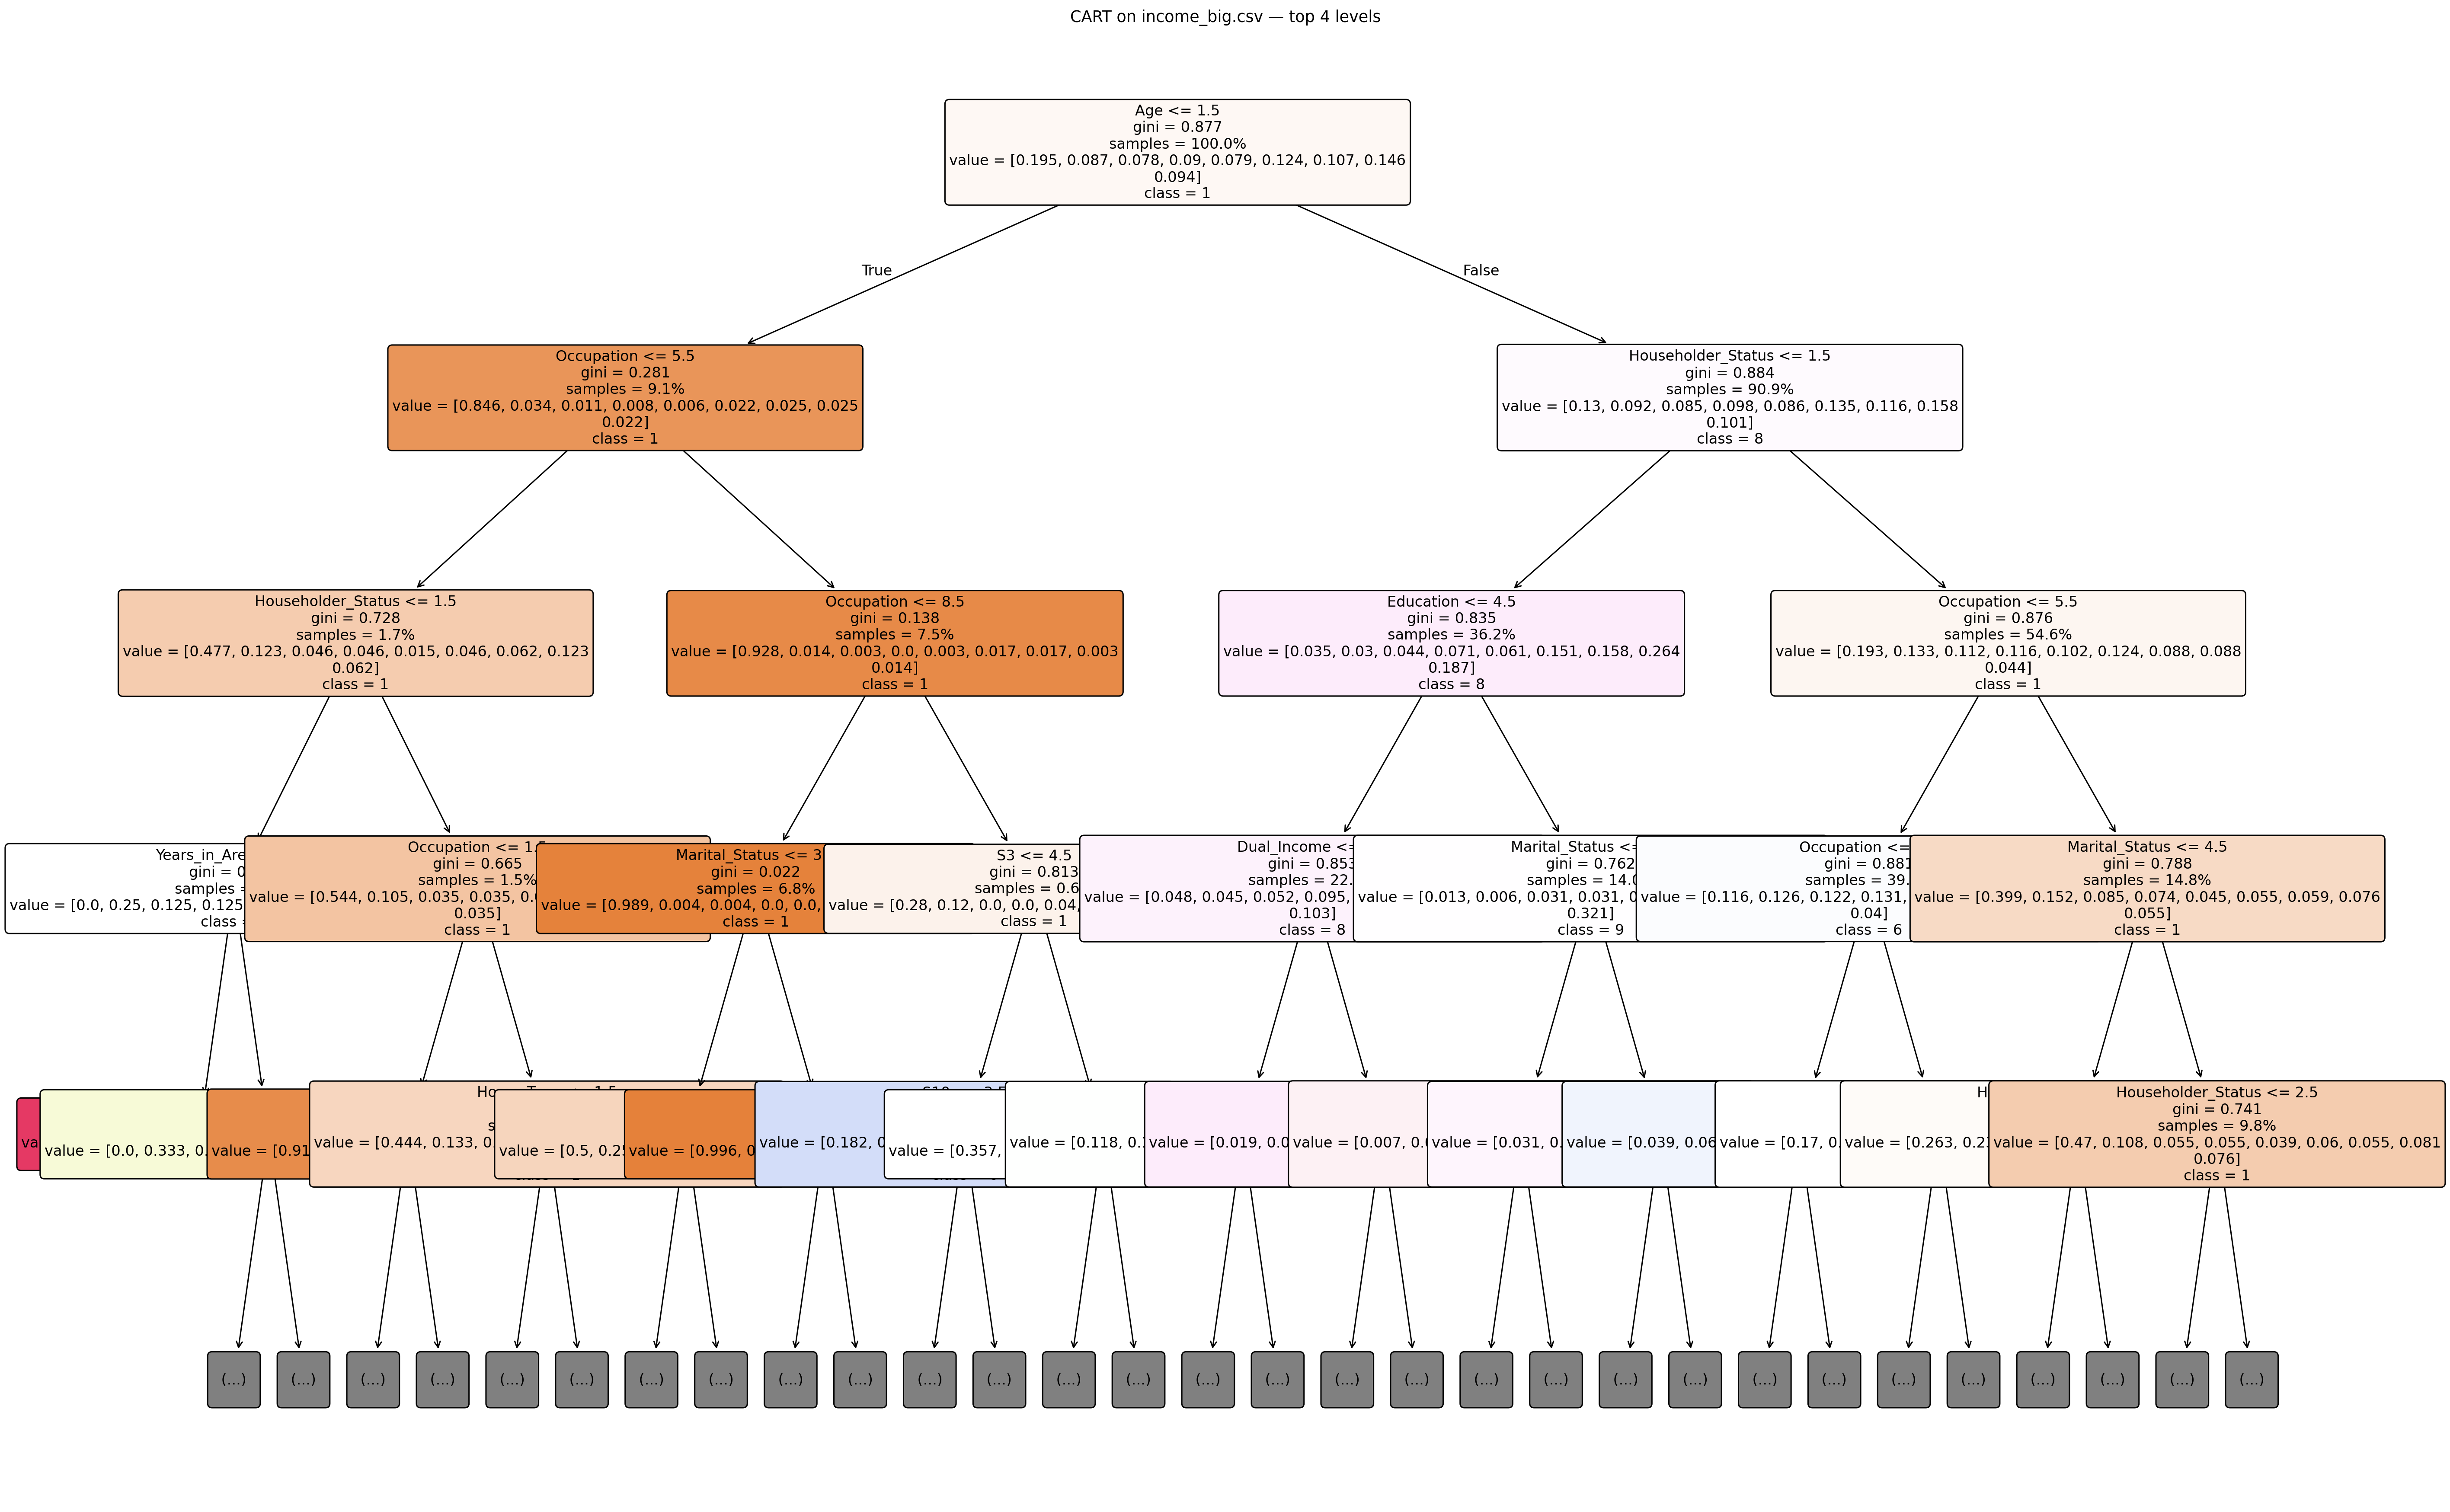

In [21]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Features / target
X_big = clean_df_big.drop(columns=["Annual_Income"])
y_big = clean_df_big["Annual_Income"]

# 60/40 split, stratified
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    X_big, y_big, test_size=0.40, random_state=42, stratify=y_big
)

# Default CART (C&R) tree
dt_big = DecisionTreeClassifier(random_state=42)
dt_big.fit(Xtr_b, ytr_b)

# Evaluate
yp_train_b = dt_big.predict(Xtr_b)
yp_test_b  = dt_big.predict(Xte_b)

acc_tr_b = accuracy_score(ytr_b, yp_train_b)
acc_te_b = accuracy_score(yte_b, yp_test_b)
f1m_te_b = f1_score(yte_b, yp_test_b, average="macro")

print(f"BIG Tree — Train Acc: {acc_tr_b:.4f} | Test Acc: {acc_te_b:.4f} | Test Macro F1: {f1m_te_b:.4f}")
print(f"Depth: {dt_big.get_depth()} | Leaves: {dt_big.get_n_leaves()}")

print("\nClassification Report (BIG test):")
print(classification_report(yte_b, yp_test_b))
print("Confusion Matrix (BIG test):")
print(confusion_matrix(yte_b, yp_test_b))

import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 220
plt.figure(figsize=(26,16))
plot_tree(
    dt_big,
    feature_names=X_big.columns,
    class_names=[str(c) for c in sorted(y_big.unique())],
    filled=True, rounded=True, proportion=True,
    max_depth=4, fontsize=11
)
plt.title("CART on income_big.csv — top 4 levels")
plt.tight_layout()
plt.show()



In [22]:
fi_big = pd.Series(dt_big.feature_importances_, index=X_big.columns).sort_values(ascending=False)
print("\nTop 20 feature importances:")
print(fi_big.head(20))

# Summarize real vs spurious
REAL_FEATURES = BASE_COLUMNS[1:]  # exclude Annual_Income
real_importance     = fi_big.loc[REAL_FEATURES].sum()
spurious_importance = fi_big.loc[SPURIOUS_COLUMNS].sum()

print(f"\nImportance share — Real: {real_importance:.3f} | Spurious: {spurious_importance:.3f}")




Top 20 feature importances:
Age                   0.087830
S9                    0.071977
S6                    0.062387
S8                    0.061570
S2                    0.060783
S1                    0.060582
S3                    0.060483
S10                   0.060255
S7                    0.059093
S4                    0.059060
S5                    0.058190
Occupation            0.050559
Household_Size        0.034221
Education             0.034089
Householder_Status    0.030737
Years_in_Area         0.028479
Marital_Status        0.025340
Ethnicity             0.024304
Sex                   0.017366
Home_Type             0.016519
dtype: float64

Importance share — Real: 0.386 | Spurious: 0.614


In [23]:
# Comparing Original Model to New BIG Model

from sklearn.metrics import f1_score

# Original CART
yp_train_orig = dt_default.predict(X_train)
yp_test_orig  = dt_default.predict(X_test)

acc_tr_orig = accuracy_score(y_train, yp_train_orig)
acc_te_orig = accuracy_score(y_test, yp_test_orig)
f1m_te_orig = f1_score(y_test, yp_test_orig, average="macro")

err_tr_orig = 1 - acc_tr_orig
err_te_orig = 1 - acc_te_orig

depth_orig  = dt_default.get_depth()
nodes_orig = dt_default.tree_.node_count
leaves_orig = dt_default.get_n_leaves()

tree = dt_default.tree_
leaf_ids = np.where(tree.children_left == -1)[0]
leaf_sizes = tree.n_node_samples[leaf_ids]

leaf_stats_orig = {
    "avg_leaf_size": leaf_sizes.mean(),
    "min_leaf_size": leaf_sizes.min(),
    "max_leaf_size": leaf_sizes.max()
}


# BIG CART
yp_train_big = dt_big.predict(Xtr_b)
yp_test_big  = dt_big.predict(Xte_b)

acc_tr_big = accuracy_score(ytr_b, yp_train_big)
acc_te_big = accuracy_score(yte_b, yp_test_big)
f1m_te_big = f1_score(yte_b, yp_test_big, average="macro")

err_tr_big  = 1 - acc_tr_big
err_te_big  = 1 - acc_te_big

depth_big  = dt_big.get_depth()
nodes_big  = dt_big.tree_.node_count
leaves_big = dt_big.get_n_leaves()

tree_big = dt_big.tree_
leaf_ids_big = np.where(tree_big.children_left == -1)[0]
leaf_sizes_big = tree_big.n_node_samples[leaf_ids_big]

leaf_stats_big = {
    "avg_leaf_size": leaf_sizes_big.mean(),
    "min_leaf_size": leaf_sizes_big.min(),
    "max_leaf_size": leaf_sizes_big.max()
}

# PRINT COMPARISON

compare = pd.DataFrame({
    "Model": ["Original CART", "BIG CART"],
    "Train Accuracy": [acc_tr_orig, acc_tr_big],
    "Train Error":    [err_tr_orig, err_tr_big],
    "Test Accuracy":  [acc_te_orig, acc_te_big],
    "Test Error":     [err_te_orig,  err_te_big],
    "Test Macro F1":  [f1m_te_orig, f1m_te_big],
    "Depth":          [depth_orig, depth_big],
    "Nodes":          [nodes_orig,    nodes_big],
    "Leaves":         [leaves_orig, leaves_big],
    "Avg Leaf Size":  [leaf_stats_orig["avg_leaf_size"], leaf_stats_big["avg_leaf_size"]],
    "Min Leaf Size":  [leaf_stats_orig["min_leaf_size"], leaf_stats_big["min_leaf_size"]],
    "Max Leaf Size":  [leaf_stats_orig["max_leaf_size"], leaf_stats_big["max_leaf_size"]],
})
compare



,Model,Train Accuracy,Train Error,Test Accuracy,Test Error,Test Macro F1,Depth,Nodes,Leaves,Avg Leaf Size,Min Leaf Size,Max Leaf Size
0,Original CART,0.911585,0.088415,0.281823,0.718177,0.240283,28,6325,3163,1.705659,1,397
1,BIG CART,1.000000,0.000000,0.249232,0.750768,0.212175,25,3559,1780,2.193258,1,258


## Part H
Create two more C&R trees. Change the parameters of the tree such that you get a tree as large as possible (minimum-pruning). The other does prune with making sure you require at least 500 records in a parent nodes and 100 records in leaf nodes.

In [24]:
# Helper function to train & summarize trees

def train_eval_tree(X_tr, y_tr, X_te, y_te, name="CART", **tree_kwargs):
    """
    Train a CART tree and return performance + structural stats.
    """
    # Build classifier without the 'name' argument
    clf = DecisionTreeClassifier(random_state=42, **tree_kwargs)
    clf.fit(X_tr, y_tr)

    yp_tr = clf.predict(X_tr)
    yp_te = clf.predict(X_te)

    acc_tr = accuracy_score(y_tr, yp_tr)
    acc_te = accuracy_score(y_te, yp_te)
    f1m_te = f1_score(y_te, yp_te, average="macro")

    t = clf.tree_
    leaf_ids = np.where(t.children_left == -1)[0]
    leaf_sizes = t.n_node_samples[leaf_ids]

    return {
        "Model": name,
        "Train Accuracy": acc_tr,
        "Train Error": 1 - acc_tr,
        "Test Accuracy": acc_te,
        "Test Error": 1 - acc_te,
        "Test Macro F1": f1m_te,
        "Depth": clf.get_depth(),
        "Nodes": t.node_count,
        "Leaves": clf.get_n_leaves(),
        "Avg Leaf Size": float(leaf_sizes.mean()),
        "Min Leaf Size": int(leaf_sizes.min()),
        "Max Leaf Size": int(leaf_sizes.max()),
        "estimator": clf
    }


In [25]:
# Max-size (minimum pruning) tree
orig_max = train_eval_tree(
    X_train, y_train, X_test, y_test,
    name="Original Data: Max-size",
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None
)

# Heavily-pruned tree (≥500 parent, ≥100 leaf)
orig_pruned = train_eval_tree(
    X_train, y_train, X_test, y_test,
    name="Original Data: Pruned (500/100)",
    min_samples_split=500,
    min_samples_leaf=100,
    max_depth=None
)

# Comparison table
pd.DataFrame([
    {k:v for k,v in orig_max.items() if k != "estimator"},
    {k:v for k,v in orig_pruned.items() if k != "estimator"},
])


,Model,Train Accuracy,Train Error,Test Accuracy,Test Error,Test Macro F1,Depth,Nodes,Leaves,Avg Leaf Size,Min Leaf Size,Max Leaf Size
0,Original Data: Max-size,0.911585,0.088415,0.281823,0.718177,0.240283,28,6325,3163,1.705659,1,397
1,Original Data: Pruned (500/100),0.348285,0.651715,0.327682,0.672318,0.209369,6,35,18,299.722222,166,455


In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Helper function to plot trees

def plot_cart_preview(clf, feature_names, class_names, title,
                      max_depth=4, figsize=(26, 16), dpi=220, fontsize=11):
    """
    Plots a readable preview of a fitted CART tree (top `max_depth` levels).
    """
    plt.rcParams['figure.dpi'] = dpi
    plt.figure(figsize=figsize)
    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=[str(c) for c in sorted(set(class_names))],
        filled=True,
        rounded=True,
        proportion=True,
        max_depth=max_depth,
        fontsize=fontsize
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()



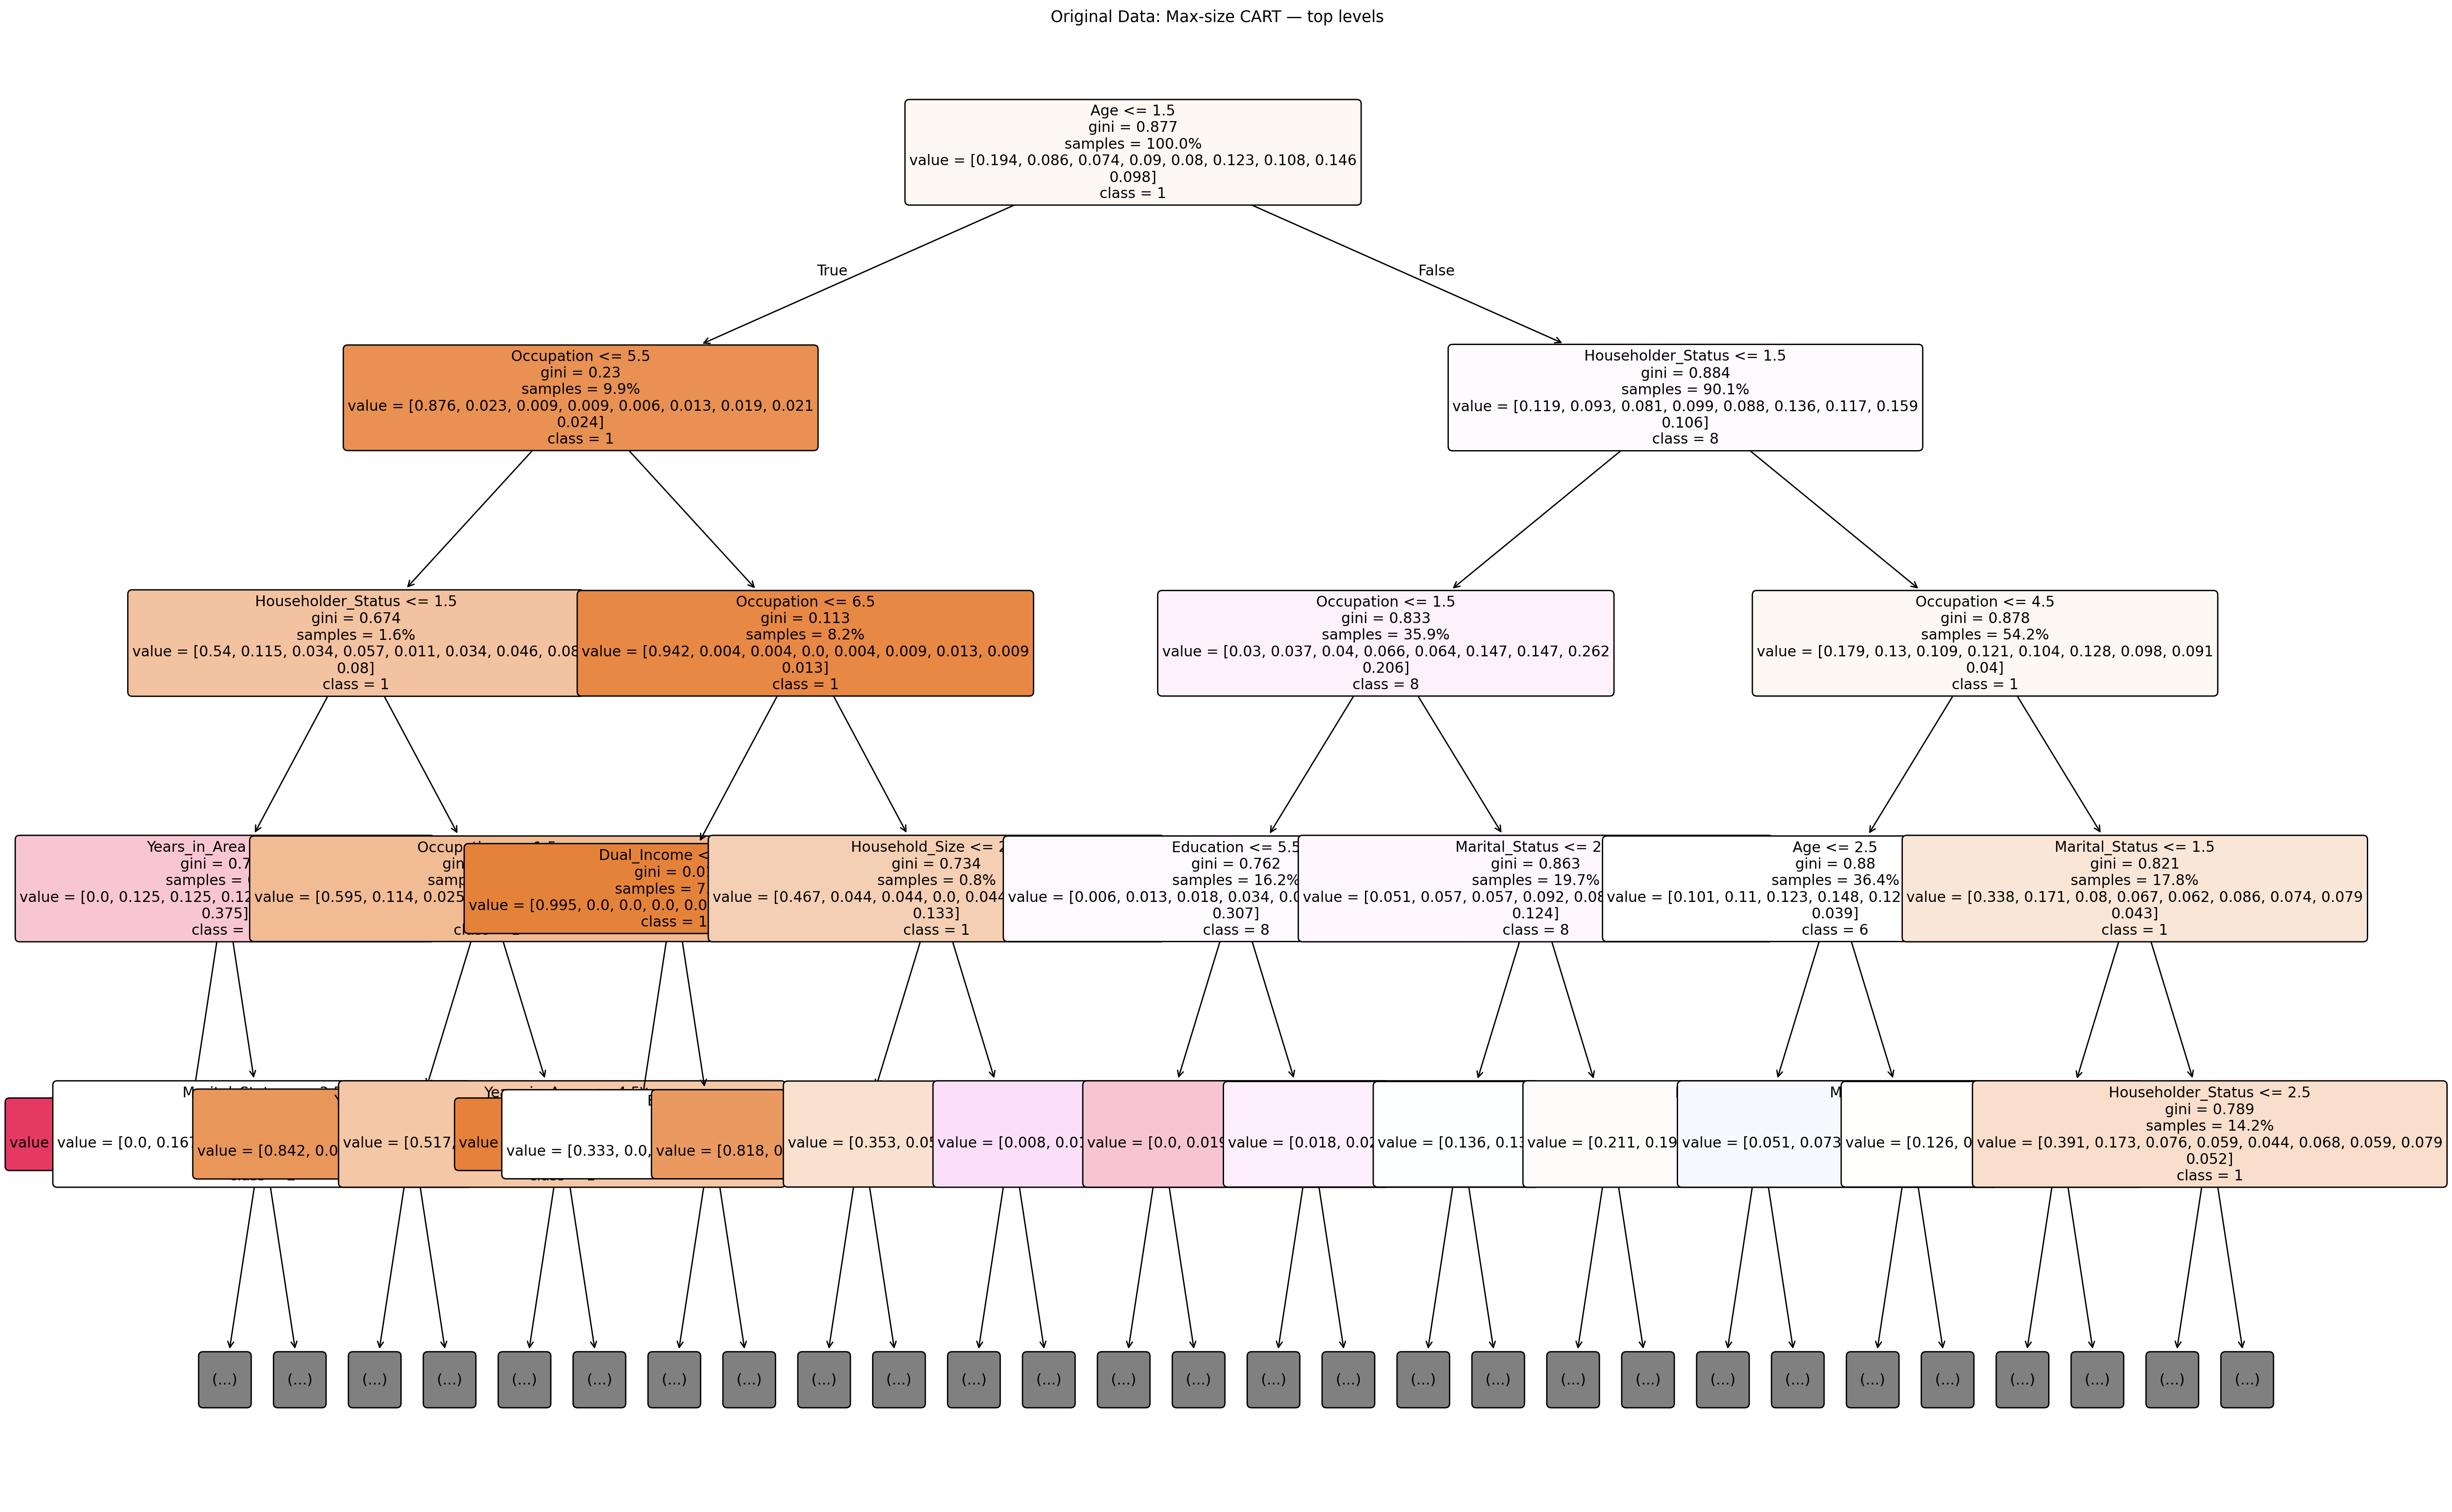

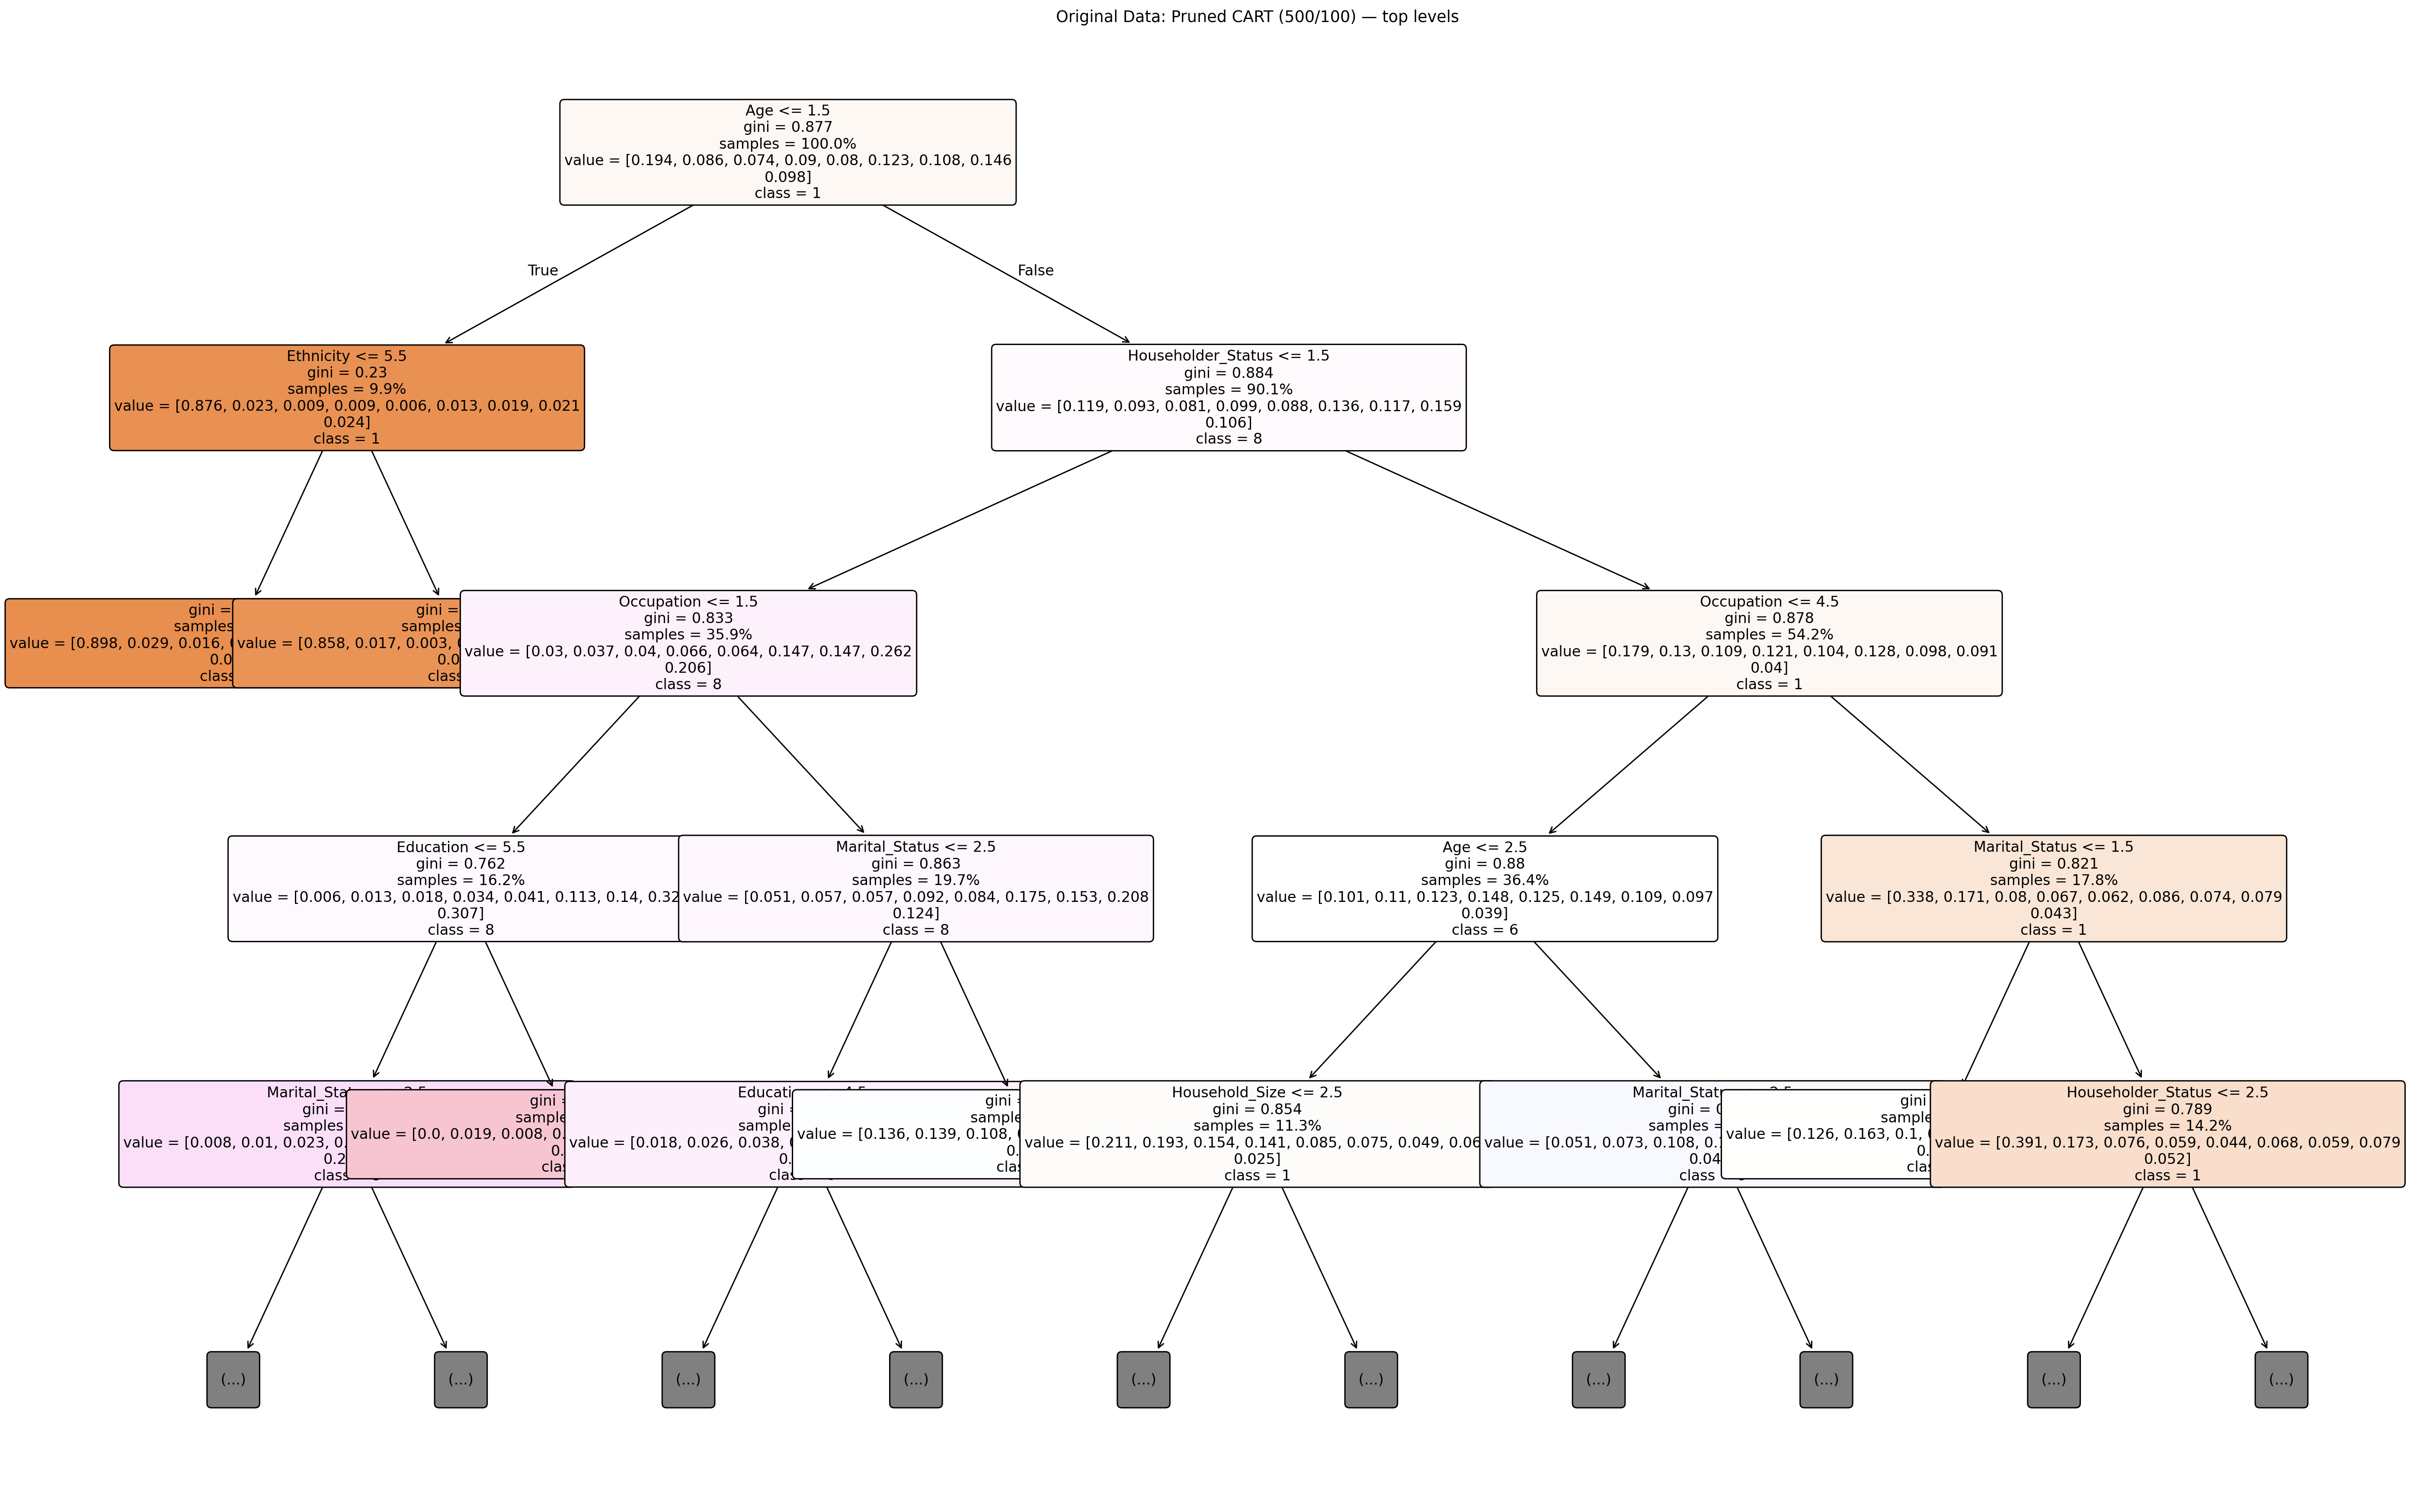

In [27]:
# Plotting the two trees
feature_names = X_train.columns
class_names   = y_train.unique()

plot_cart_preview(
    orig_max["estimator"], feature_names, class_names,
    title="Original Data: Max-size CART — top levels", max_depth=4
)

plot_cart_preview(
    orig_pruned["estimator"], feature_names, class_names,
    title="Original Data: Pruned CART (500/100) — top levels", max_depth=4
)

## Part I
In this part we want to check the effect of the size of training and testing data on the quality of the predictions. Construct a decision tree on different size of training data and compare the results. For example, consider a partition of the data into 50% for Training and 50% for Testing. What model performance do you obtain? Consider partitions of the data into 70% for Training and 30% for Testing, and 90% for Training and 10% for Testing and report on model and performance comparisons.

In [28]:
from sklearn.model_selection import train_test_split

# Function to run one experiment with a given split ratio
def run_split_experiment(X, y, train_size, name="CART"):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, train_size=train_size, random_state=42, stratify=y
    )
    return train_eval_tree(X_tr, y_tr, X_te, y_te, name=name)

# Run experiments
tree_50 = run_split_experiment(X, y, train_size=0.50, name="Original: 50/50")
tree_70 = run_split_experiment(X, y, train_size=0.70, name="Original: 70/30")
tree_90 = run_split_experiment(X, y, train_size=0.90, name="Original: 90/10")

# Compare results
compare_splits = pd.DataFrame([
    {k:v for k,v in tree_50.items() if k != "estimator"},
    {k:v for k,v in tree_70.items() if k != "estimator"},
    {k:v for k,v in tree_90.items() if k != "estimator"},
])
compare_splits


,Model,Train Accuracy,Train Error,Test Accuracy,Test Error,Test Macro F1,Depth,Nodes,Leaves,Avg Leaf Size,Min Leaf Size,Max Leaf Size
0,Original: 50/50,0.918149,0.081851,0.269291,0.730709,0.229402,33,5341,2671,1.683265,1,329
1,Original: 70/30,0.902303,0.097697,0.282802,0.717198,0.239987,33,7319,3660,1.719945,1,463
2,Original: 90/10,0.894353,0.105647,0.284444,0.715556,0.243612,33,9321,4661,1.736323,1,588


## Part J
Construct two decision trees, once using “gini” measure once using “information gain” and try to keep the other parameters the same.

In [29]:
# 70/30 split selected in the previous answer
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.70, random_state=42, stratify=y
)

# Tree with Gini
tree_gini = train_eval_tree(
    X_tr, y_tr, X_te, y_te,
    name="Original: CART (Gini)",
    criterion="gini",
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None
)

# Tree with Entropy (Information Gain)
tree_entropy = train_eval_tree(
    X_tr, y_tr, X_te, y_te,
    name="Original: CART (Entropy)",
    criterion="entropy",
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None
)

# Compare results
compare_criteria = pd.DataFrame([
    {k:v for k,v in tree_gini.items() if k != "estimator"},
    {k:v for k,v in tree_entropy.items() if k != "estimator"},
])
compare_criteria


,Model,Train Accuracy,Train Error,Test Accuracy,Test Error,Test Macro F1,Depth,Nodes,Leaves,Avg Leaf Size,Min Leaf Size,Max Leaf Size
0,Original: CART (Gini),0.902303,0.097697,0.282802,0.717198,0.239987,33,7319,3660,1.719945,1,463
1,Original: CART (Entropy),0.902303,0.097697,0.274277,0.725723,0.229871,24,7485,3743,1.681806,1,463


## Part K

Train a Random Forest classifier on the training data (using the same 60/40 split as in part b). Use an ensemble of 100 trees (n_estimators=100) and set random_state=42 for reproducibility. What is the Out-of- Bag (OOB) error estimate of your model?


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True  # Enable OOB error calculation
)

rf_model.fit(X_train, y_train)

# OOB error estimate
oob_error = 1 - rf_model.oob_score_
print(f"Out-of-Bag (OOB) Error Estimate: {oob_error:.4f}")
print(f"OOB Accuracy: {rf_model.oob_score_:.4f}")

Out-of-Bag (OOB) Error Estimate: 0.6884
OOB Accuracy: 0.3116


## Part L
Plot the feature importances as determined by the Random Forest model. How does the ranking of the most important features compare to the major predictors you identified in the single decision tree (part c)? Provide a brief explanation for any similarities or differences

Random Forest Feature Importances:
               Feature  Importance
2                  Age    0.134535
4           Occupation    0.123526
3            Education    0.118285
7       Household_Size    0.102142
5        Years_in_Area    0.088392
11           Ethnicity    0.087645
10           Home_Type    0.065750
8        Under18_in_HH    0.061038
1       Marital_Status    0.054528
0                  Sex    0.052770
9   Householder_Status    0.049499
6          Dual_Income    0.037140
12            Language    0.024749

Single Decision Tree Feature Importances:
               Feature  Importance
2                  Age    0.153278
4           Occupation    0.104779
7       Household_Size    0.100513
11           Ethnicity    0.099693
3            Education    0.097271
5        Years_in_Area    0.094544
10           Home_Type    0.084976
8        Under18_in_HH    0.063767
1       Marital_Status    0.053440
0                  Sex    0.047984
9   Householder_Status    0.039072
6          D

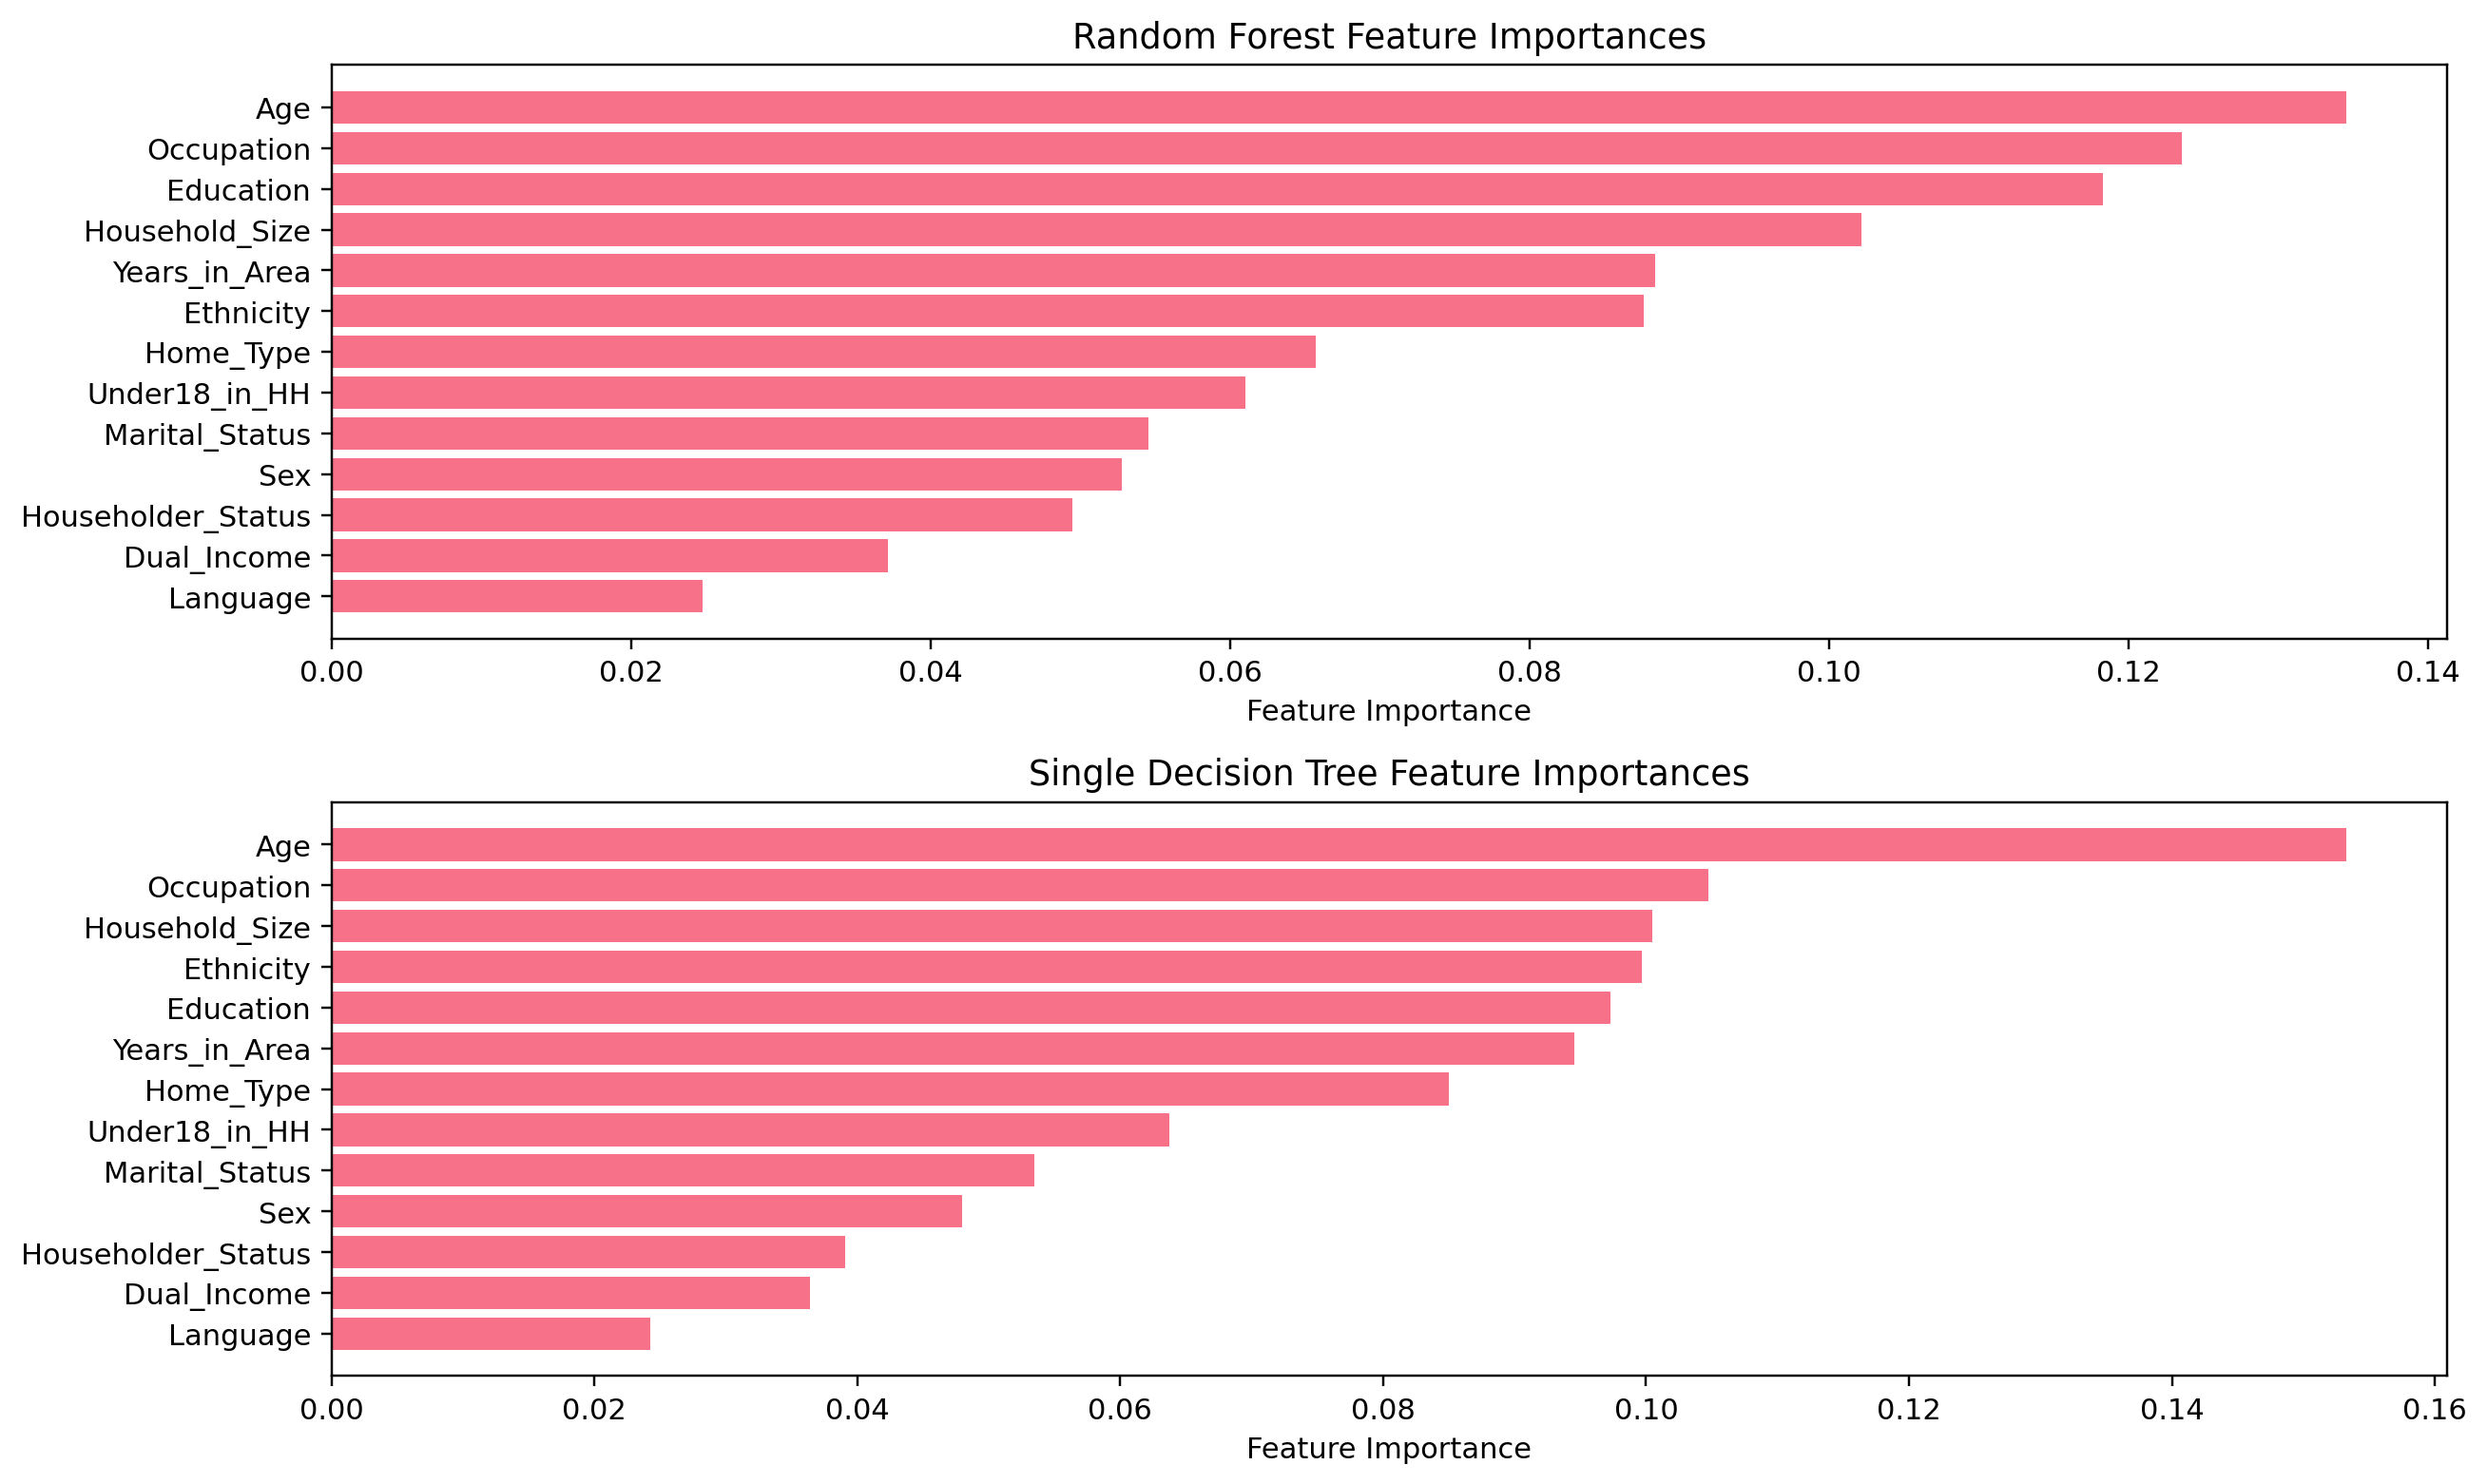

In [31]:

# Get feature importances from Random Forest from part k
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importances:")
print(importance_df)

# Plot feature importances
plt.figure(figsize=(12, len(feature_names) * 0.4 + 2))
plt.subplot(2, 1, 1)
all_features = importance_df
plt.barh(range(len(all_features)), all_features['Importance'])
plt.yticks(range(len(all_features)), all_features['Feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()

# Retrain the decision tree to compare
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Feature importances from decision tree
dt_importances = dt_model.feature_importances_
dt_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_importances
}).sort_values('Importance', ascending=False)

print("\nSingle Decision Tree Feature Importances:")
print(dt_importance_df)

plt.subplot(2, 1, 2)
dt_all_features = dt_importance_df
plt.barh(range(len(dt_all_features)), dt_all_features['Importance'])
plt.yticks(range(len(dt_all_features)), dt_all_features['Feature'])
plt.xlabel('Feature Importance')
plt.title('Single Decision Tree Feature Importances')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



## Part M
Predict the annual income of households in the test set using the Random Forest model. Calculate the prediction error and compare it to the error you obtained from the single decision tree in part (e). Which model performs better on the test set?

In [32]:
# Using the random forest model to calculate error
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_error = 1 - rf_accuracy


print(f"Random Forest Test Error: {rf_error:.4f}")
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")


print(f"\nImprovement with Random Forest: {error_rate - rf_error:.4f}")  #error_rate is from part E it is the error rate of the single decision tree

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))



Random Forest Test Error: 0.6932
Random Forest Test Accuracy: 0.3068

Improvement with Random Forest: 0.0250

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.69      0.63       698
           2       0.18      0.16      0.17       310
           3       0.18      0.12      0.15       267
           4       0.15      0.13      0.14       325
           5       0.16      0.13      0.15       289
           6       0.22      0.23      0.22       444
           7       0.18      0.18      0.18       388
           8       0.30      0.33      0.31       523
           9       0.34      0.31      0.32       354

    accuracy                           0.31      3598
   macro avg       0.25      0.25      0.25      3598
weighted avg       0.29      0.31      0.30      3598



## Part N
Experiment with the number of trees in the forest. Train models with n_estimators = [10, 50, 100, 200] and plot the OOB error against the number of trees. At what point does the error seem to stabilize? What is the trade-off in using more trees?

Training models with different numbers of trees:
Training with 10 trees:
  OOB Error: 0.7190
  Test Error: 0.7057
Training with 50 trees:
  OOB Error: 0.6947
  Test Error: 0.6943
Training with 100 trees:
  OOB Error: 0.6884
  Test Error: 0.6932
Training with 200 trees:
  OOB Error: 0.6875
  Test Error: 0.6870

Summary of Results:
   n_estimators  OOB_Error  Test_Error
0            10   0.718999    0.705670
1            50   0.694717    0.694275
2           100   0.688415    0.693163
3           200   0.687488    0.687048
Minimum OOB Error: 0.6875 at 200 trees


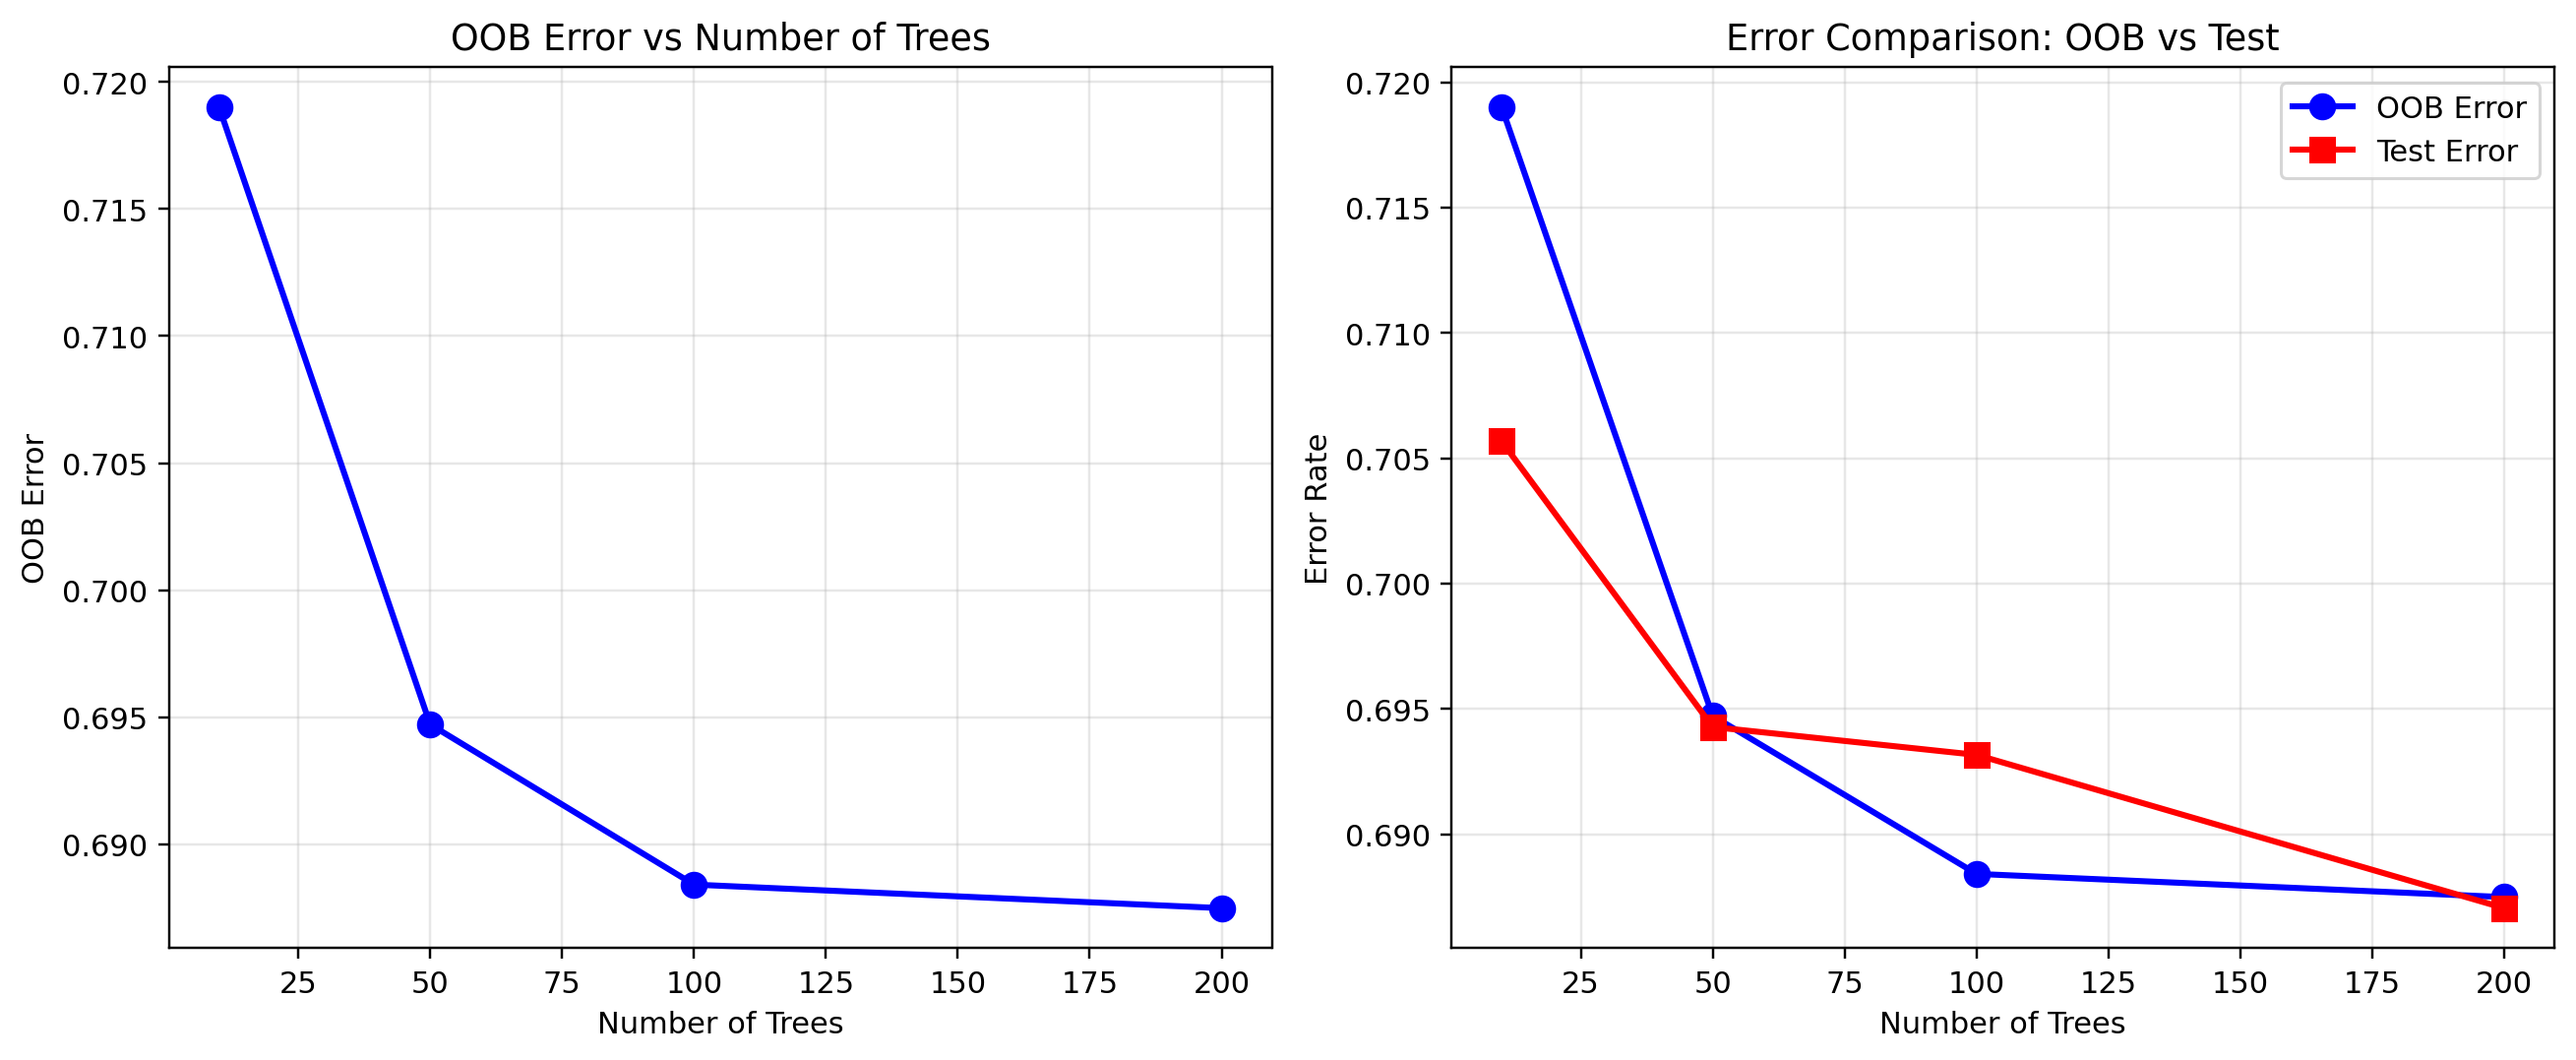

In [33]:
n_estimators_list = [10, 50, 100, 200]
oob_errors = []
test_errors = []

print("Training models with different numbers of trees:")

for n_trees in n_estimators_list:
    print(f"Training with {n_trees} trees:")

    # Training model with specific number of trees
    rf_temp = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        oob_score=True
    )
    rf_temp.fit(X_train, y_train)

    # OOB error
    oob_error_temp = 1 - rf_temp.oob_score_
    oob_errors.append(oob_error_temp)

    # Test error
    test_pred_temp = rf_temp.predict(X_test)
    test_error_temp = 1 - accuracy_score(y_test, test_pred_temp)
    test_errors.append(test_error_temp)

    print(f"  OOB Error: {oob_error_temp:.4f}")
    print(f"  Test Error: {test_error_temp:.4f}")


results_df = pd.DataFrame({
    'n_estimators': n_estimators_list,
    'OOB_Error': oob_errors,
    'Test_Error': test_errors
})

print("\nSummary of Results:")
print(results_df)

# This is where error stabilizes (minimal improvement)
min_oob_error = min(oob_errors)
min_oob_index = oob_errors.index(min_oob_error)
best_n_trees = n_estimators_list[min_oob_index]

print(f"Minimum OOB Error: {min_oob_error:.4f} at {best_n_trees} trees")

# OOB error vs number of trees
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_list, oob_errors, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error')
plt.title('OOB Error vs Number of Trees')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_estimators_list, oob_errors, 'b-o', label='OOB Error', linewidth=2, markersize=8)
plt.plot(n_estimators_list, test_errors, 'r-s', label='Test Error', linewidth=2, markersize=8)
plt.xlabel('Number of Trees')
plt.ylabel('Error Rate')
plt.title('Error Comparison: OOB vs Test')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



